# Ejemplo de uso de Python para el análisis cualitativo de un sistema no lineal: Péndulo Invertido

Antes de nada, importamos las librerías que vamos a necesitar en todo el notebook.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

## Función de las ecuaciones de estado
$$
\dot x_1 = x_2\\
\dot x_2 = \frac{g}{l}\sin x_1 - \frac{b}{ml}x_2
$$

In [3]:
def pendulo_inv(t, x, m, l, g, b):
    """
    Ecuaciones de estado del péndulo invertido con friccion viscosa.

    t : tiempo (s). Este sistema es autonomo, no depende del tiempo, pero a la
        funcion hay que pasarle las variables en el orden t, x, parametros para
        que sea compatible con los integradores de scipy (solve_ivp). Por
        supuesto, luego no se emplea el tiempo para nada.

    x : vector de variables de estado [theta, theta_dot]
        x[0] angulo del pendulo con la vertical (semieje positivo) (rad)
        x[1] velocidad angular (rad/s)

    m : masa del pendulo (Kg)
    l : longitud del pendulo (m)
    g : aceleracion de la gravedad (m/s^2)
    b : coeficiente de friccion (Kg*m/s)

    Devuelve xdot = [velocidad angular, aceleracion angular]
    """
    x1, x2 = x
    xdot1 = x2
    xdot2 = (g*np.sin(x1) - b*x2/m) / l
    return [xdot1, xdot2]

## 1. Cálculo de una trayectoria en el espacio de las fases

Vamos a emplear para el cálculo la función `pendulo_inv` definida arriba, con las ecuaciones de estado del sistema.

Para calcular una trayectoria definimos en primer lugar un intervalo de tiempo para el cálculo, `t = [t1, tf]`.

In [4]:
tin = [0, 15]  # intervalo de integracion

Además debemos dar valor a todos los parámetros,

In [5]:
g1 = 10   # gravedad
m1 = 10   # masa
l1 = 10   # longitud
b1 = 100  # resistencia viscosa

Por último, debemos suministrar una condición inicial,

In [6]:
x0 = [np.pi/3, 0]  # [angulo inicial (rad), velocidad angular inicial (rad/s)]

A continuación llamamos a `solve_ivp`, un integrador estándar. Ver detalles en la documentación de scipy.

In [7]:
sol = solve_ivp(
    pendulo_inv, tin, x0, args=(m1, l1, g1, b1), max_step=0.05
)
t = sol.t
x = sol.y.T  # transponemos para que cada fila sea un instante,

Podemos ahora representar la evolución temporal de las variables de estado,

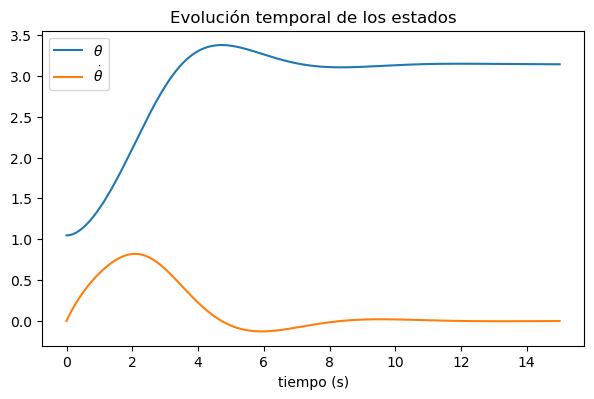

In [8]:
fig = plt.figure(1, figsize=(7, 9))

plt.subplot(2, 1, 1)
plt.plot(t, x[:, 0], label=r'$\theta$')
plt.plot(t, x[:, 1], label=r'$\dot{\theta}$')
plt.title('Evolución temporal de los estados')
plt.xlabel('tiempo (s)')
plt.legend()

Dibujamos también la trayectoria en el plano de fases,

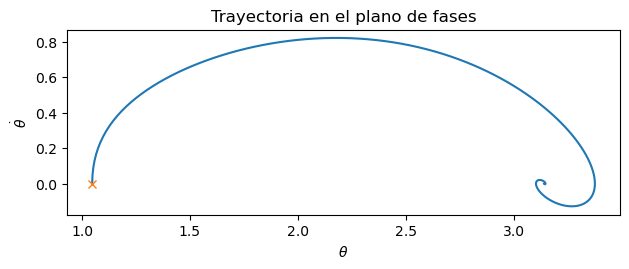

In [9]:
plt.subplot(2, 1, 2)
plt.plot(x[:, 0], x[:, 1])
plt.plot(x0[0], x0[1], 'x')
plt.title('Trayectoria en el plano de fases')
plt.xlabel(r'$\theta$')
plt.ylabel(r'$\dot{\theta}$')
plt.tight_layout()
plt.show()

## 2. Representación del campo vectorial asociado al sistema

Para este cálculo empezamos por obtener un conjunto de puntos sobre los que obtener los valores del campo. En este caso, sabemos la posición de los puntos de equilibrio, parece interesante seleccionar una región que contenga varios,

In [10]:
x1 = np.arange(-3*np.pi/2, 3*np.pi/2 + 1e-9, 3*np.pi/18)
x2 = np.arange(-3, 3 + 1e-9, 0.3)

Una manera rápida de construir un mallado de puntos que contenga todos los pares de los valores anteriores es usar `np.meshgrid`,

In [11]:
x1m, x2m = np.meshgrid(x1, x2)
xdot1m = x2m                                    # calculamos las componentes del campo
xdot2m = (g1*np.sin(x1m) - b1*x2m/m1) / l1

Usamos `plt.quiver` (equivalente a `quiver` de MATLAB) para representar, en cada punto de la malla creada, el vector asociado en el plano de fases,

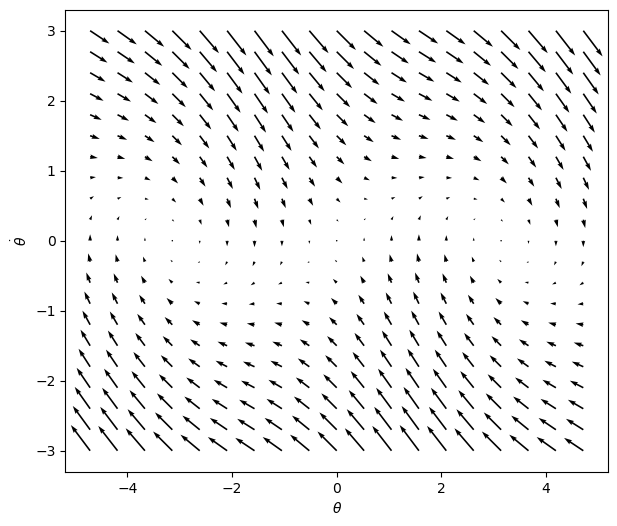

In [12]:
plt.figure(2, figsize=(7, 6))
plt.quiver(x1m, x2m, xdot1m, xdot2m)
# plt.axis('equal')
plt.axis('tight')
plt.xlabel(r'$\theta$')
plt.ylabel(r'$\dot{\theta}$')
plt.show()

Por último, superponemos varias trayectorias partiendo de una malla más gruesa de condiciones iniciales, para completar el plano de fases,

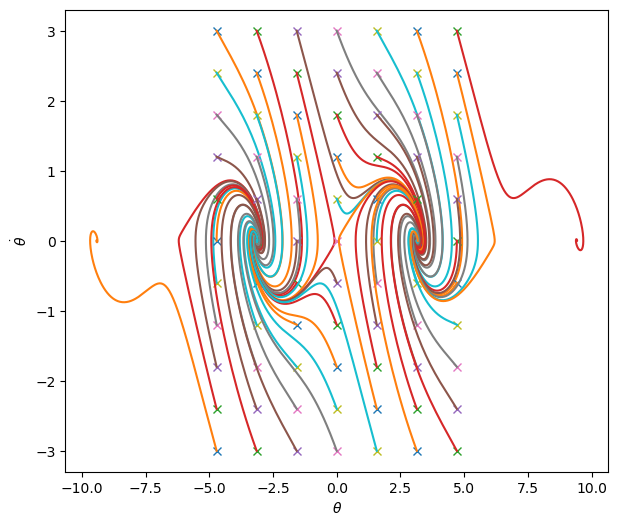

In [13]:
x1_grid = np.arange(-3*np.pi/2, 3*np.pi/2 + 1e-9, 3*np.pi/6)
x2_grid = np.arange(-3, 3 + 1e-9, 0.6)

plt.figure(3, figsize=(7, 6))

for i in x1_grid:
    for j in x2_grid:
        sol_ij = solve_ivp(
    pendulo_inv, tin, [i, j], args=(m1, l1, g1, b1), max_step=0.05
    )
        
        plt.plot(i, j, 'x')
        plt.plot(sol_ij.y[0], sol_ij.y[1])

# plt.axis('equal')
# plt.axis('tight')
plt.xlabel(r'$\theta$')
plt.ylabel(r'$\dot{\theta}$')
plt.show()